In [ ]:
# =============================================================================
# NOTEBOOK 2: FEATURE ENGINEERING
# =============================================================================
# Purpose: Extract temporal traffic features from the cleaned dataset.
# These features capture time-of-day patterns, day-of-week patterns,
# speed variability, congestion indicators, and other temporal characteristics
# that will be used for unsupervised clustering.
# =============================================================================


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Load the cleaned dataset from Notebook 1
df_clean = pd.read_hdf('../data/metr_la_cleaned.h5')
print(f"Loaded cleaned dataset: {df_clean.shape}")
print(f"Time range: {df_clean.index[0]} to {df_clean.index[-1]}")


Loaded cleaned dataset: (34272, 207)
Time range: 2012-03-01 00:00:00 to 2012-06-27 23:55:00


In [2]:
# ---- Cell 2: Extract Basic Temporal Features ----
# Extract time-related attributes from the datetime index
# These features help identify temporal patterns in traffic

print("=" * 60)
print("EXTRACTING BASIC TEMPORAL FEATURES")
print("=" * 60)

# Create a temporal features DataFrame
# Each row represents one time step with features aggregated across all sensors

temporal_df = pd.DataFrame(index=df_clean.index)

# Hour of the day (0-23) - captures daily traffic patterns
temporal_df['hour'] = df_clean.index.hour

# Minute of the hour (0-55 in 5-min steps) - finer time granularity
temporal_df['minute'] = df_clean.index.minute

# Time of day as continuous variable (0.0 to 23.99)
# This is better for modeling than separate hour/minute
temporal_df['time_of_day'] = temporal_df['hour'] + temporal_df['minute'] / 60.0

# Day of week (0=Monday, 6=Sunday)
temporal_df['day_of_week'] = df_clean.index.dayofweek

# Is weekend (binary: 1 for Saturday/Sunday, 0 for weekdays)
# Traffic patterns differ significantly between weekdays and weekends
temporal_df['is_weekend'] = (temporal_df['day_of_week'] >= 5).astype(int)

# Day of month (1-31)
temporal_df['day_of_month'] = df_clean.index.day

# Week of year
# FIX: isocalendar().week returns a nullable IntegerArray; cast to plain numpy int64
temporal_df['week_of_year'] = df_clean.index.isocalendar().week.astype(int).values

# Month (3-6 for March to June)
temporal_df['month'] = df_clean.index.month

print("Basic temporal features extracted:")
print(temporal_df.head(10))

EXTRACTING BASIC TEMPORAL FEATURES
Basic temporal features extracted:
                     hour  minute  time_of_day  day_of_week  is_weekend  \
2012-03-01 00:00:00     0       0     0.000000            3           0   
2012-03-01 00:05:00     0       5     0.083333            3           0   
2012-03-01 00:10:00     0      10     0.166667            3           0   
2012-03-01 00:15:00     0      15     0.250000            3           0   
2012-03-01 00:20:00     0      20     0.333333            3           0   
2012-03-01 00:25:00     0      25     0.416667            3           0   
2012-03-01 00:30:00     0      30     0.500000            3           0   
2012-03-01 00:35:00     0      35     0.583333            3           0   
2012-03-01 00:40:00     0      40     0.666667            3           0   
2012-03-01 00:45:00     0      45     0.750000            3           0   

                     day_of_month  week_of_year  month  
2012-03-01 00:00:00             1             9


CYCLICAL ENCODING OF TIME FEATURES
Cyclical features created: hour_sin, hour_cos, dow_sin, dow_cos, month_sin, month_cos


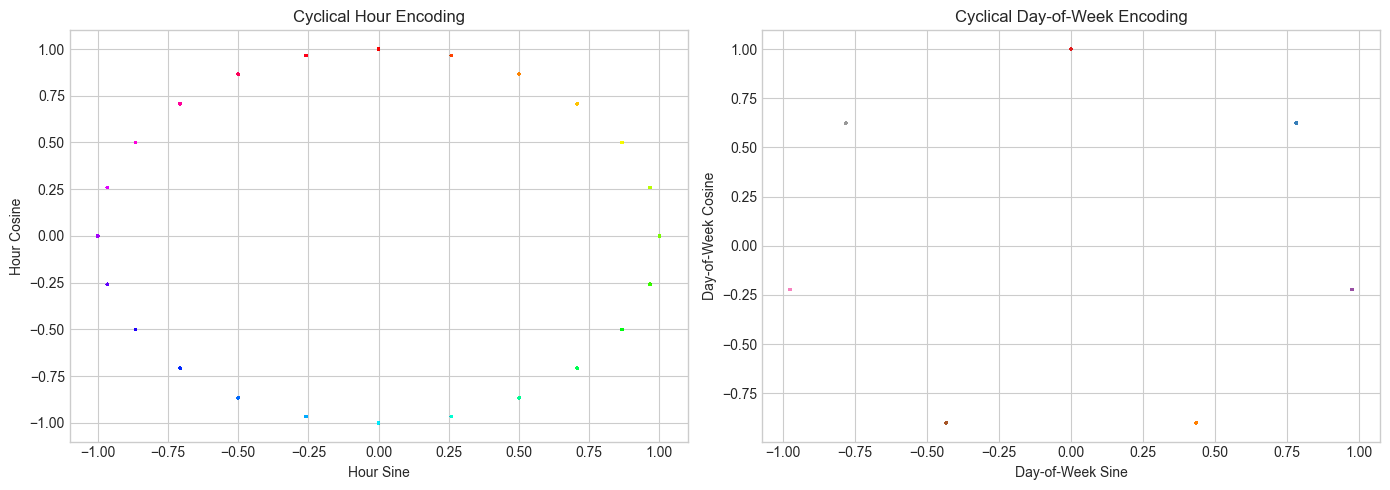

In [3]:
# ---- Cell 3: Cyclical Encoding of Time Features ----
# Time features are cyclical (hour 23 is close to hour 0)
# We use sine/cosine encoding to preserve this cyclical nature

print("\n" + "=" * 60)
print("CYCLICAL ENCODING OF TIME FEATURES")
print("=" * 60)

# Encode hour cyclically
# This ensures that hour 23 and hour 0 are close in feature space
temporal_df['hour_sin'] = np.sin(2 * np.pi * temporal_df['hour'] / 24)
temporal_df['hour_cos'] = np.cos(2 * np.pi * temporal_df['hour'] / 24)

# Encode day of week cyclically
temporal_df['dow_sin'] = np.sin(2 * np.pi * temporal_df['day_of_week'] / 7)
temporal_df['dow_cos'] = np.cos(2 * np.pi * temporal_df['day_of_week'] / 7)

# Encode month cyclically
temporal_df['month_sin'] = np.sin(2 * np.pi * temporal_df['month'] / 12)
temporal_df['month_cos'] = np.cos(2 * np.pi * temporal_df['month'] / 12)

print("Cyclical features created: hour_sin, hour_cos, dow_sin, dow_cos, month_sin, month_cos")

# Visualize cyclical encoding
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(temporal_df['hour_sin'], temporal_df['hour_cos'],
                c=temporal_df['hour'], cmap='hsv', s=1, alpha=0.3)
axes[0].set_xlabel('Hour Sine')
axes[0].set_ylabel('Hour Cosine')
axes[0].set_title('Cyclical Hour Encoding')

axes[1].scatter(temporal_df['dow_sin'], temporal_df['dow_cos'],
                c=temporal_df['day_of_week'], cmap='Set1', s=1, alpha=0.3)
axes[1].set_xlabel('Day-of-Week Sine')
axes[1].set_ylabel('Day-of-Week Cosine')
axes[1].set_title('Cyclical Day-of-Week Encoding')

plt.tight_layout()
plt.savefig('../data/cyclical_encoding.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# ---- Cell 4: Aggregate Speed Features Across Sensors ----
# For each time step, compute statistical features across all 207 sensors
# This captures the network-wide traffic state at each moment

print("=" * 60)
print("AGGREGATE SPEED FEATURES (ACROSS SENSORS)")
print("=" * 60)

# Mean speed across all sensors at each time step
# Represents the overall network traffic flow
temporal_df['mean_speed'] = df_clean.mean(axis=1)

# Median speed - more robust to outliers than mean
temporal_df['median_speed'] = df_clean.median(axis=1)

# Standard deviation - measures how much speed varies across sensors
# High std means some areas are congested while others are free-flowing
temporal_df['std_speed'] = df_clean.std(axis=1)

# Minimum speed across sensors - indicates worst congestion point
temporal_df['min_speed'] = df_clean.min(axis=1)

# Maximum speed across sensors - indicates best flow conditions
temporal_df['max_speed'] = df_clean.max(axis=1)

# Speed range (max - min) - measures spatial heterogeneity of congestion
temporal_df['speed_range'] = temporal_df['max_speed'] - temporal_df['min_speed']

# Coefficient of variation (std/mean) - normalized variability
temporal_df['cv_speed'] = temporal_df['std_speed'] / temporal_df['mean_speed']

# Percentiles to understand speed distribution across sensors
temporal_df['speed_10pct'] = df_clean.quantile(0.10, axis=1)
temporal_df['speed_25pct'] = df_clean.quantile(0.25, axis=1)
temporal_df['speed_75pct'] = df_clean.quantile(0.75, axis=1)
temporal_df['speed_90pct'] = df_clean.quantile(0.90, axis=1)

# Interquartile range (IQR) - robust measure of spread
temporal_df['iqr_speed'] = temporal_df['speed_75pct'] - temporal_df['speed_25pct']

# Skewness of speed distribution across sensors
# Negative skew means more sensors have high speeds (free flow)
temporal_df['skewness'] = df_clean.skew(axis=1)

# Kurtosis - measures how "peaked" the speed distribution is
temporal_df['kurtosis'] = df_clean.kurtosis(axis=1)

print("Aggregate speed features extracted:")
print(temporal_df[['mean_speed', 'median_speed', 'std_speed',
                    'min_speed', 'max_speed']].describe())


AGGREGATE SPEED FEATURES (ACROSS SENSORS)
Aggregate speed features extracted:
         mean_speed  median_speed     std_speed     min_speed     max_speed
count  34272.000000  34272.000000  34272.000000  34272.000000  34272.000000
mean      58.482242     62.040793     10.634546     20.086410     69.744039
std        5.371087      4.232375      4.822754     11.546080      0.400367
min       39.355749     32.666667      3.966370      0.333333     63.111111
25%       55.756661     60.793084      6.270346      9.500000     69.625000
50%       59.964107     62.750000      9.128000     17.777778     70.000000
75%       62.686466     64.750000     14.671482     32.125000     70.000000
max       66.203082     68.000000     22.771307     48.250000     70.000000


In [6]:
# ---- Cell 5: Congestion Indicator Features ----
# Define congestion thresholds and compute congestion-related features
# On LA highways, speeds below ~35 mph indicate congestion

print("\n" + "=" * 60)
print("CONGESTION INDICATOR FEATURES")
print("=" * 60)

# Define speed thresholds for different congestion levels
FREE_FLOW_THRESHOLD = 55  # mph - speeds above this are free-flowing
MODERATE_THRESHOLD = 35   # mph - speeds between 35-55 are moderate
HEAVY_CONGESTION = 20     # mph - speeds below 20 are heavily congested

# Fraction of sensors experiencing congestion at each time step
# This tells us what portion of the network is congested
temporal_df['frac_congested'] = (df_clean < MODERATE_THRESHOLD).mean(axis=1)

# Fraction of sensors with free-flowing traffic
temporal_df['frac_free_flow'] = (df_clean > FREE_FLOW_THRESHOLD).mean(axis=1)

# Fraction of sensors with heavy congestion
temporal_df['frac_heavy_congestion'] = (df_clean < HEAVY_CONGESTION).mean(axis=1)

# Number of congested sensors
temporal_df['num_congested'] = (df_clean < MODERATE_THRESHOLD).sum(axis=1)

# Binary: is there network-wide congestion? (>30% sensors congested)
temporal_df['is_network_congested'] = (temporal_df['frac_congested'] > 0.3).astype(int)

print(f"Congestion thresholds:")
print(f"  Free flow: > {FREE_FLOW_THRESHOLD} mph")
print(f"  Moderate congestion: {HEAVY_CONGESTION}-{MODERATE_THRESHOLD} mph")
print(f"  Heavy congestion: < {HEAVY_CONGESTION} mph")
print(f"\nAverage fraction congested: {temporal_df['frac_congested'].mean():.4f}")
print(f"Average fraction free flow: {temporal_df['frac_free_flow'].mean():.4f}")
print(f"Percentage of time with network congestion: "
      f"{temporal_df['is_network_congested'].mean()*100:.2f}%")



CONGESTION INDICATOR FEATURES
Congestion thresholds:
  Free flow: > 55 mph
  Moderate congestion: 20-35 mph
  Heavy congestion: < 20 mph

Average fraction congested: 0.0861
Average fraction free flow: 0.7883
Percentage of time with network congestion: 6.70%


In [7]:
# ---- Cell 6: Temporal Change Features (Speed Dynamics) ----
# Compute features that capture how quickly traffic conditions change
# These features help identify sudden congestion onset/clearance

print("\n" + "=" * 60)
print("TEMPORAL CHANGE FEATURES")
print("=" * 60)

# Speed change from previous time step (5-minute change)
# Positive = speed increasing (traffic improving)
# Negative = speed decreasing (congestion building)
temporal_df['speed_change_5min'] = temporal_df['mean_speed'].diff(1)

# Speed change over 15 minutes (3 time steps)
temporal_df['speed_change_15min'] = temporal_df['mean_speed'].diff(3)

# Speed change over 30 minutes (6 time steps)
temporal_df['speed_change_30min'] = temporal_df['mean_speed'].diff(6)

# Speed change over 1 hour (12 time steps)
temporal_df['speed_change_1hr'] = temporal_df['mean_speed'].diff(12)

# Rate of change (acceleration/deceleration of traffic)
temporal_df['speed_acceleration'] = temporal_df['speed_change_5min'].diff(1)

# Rolling standard deviation (volatility) over past 30 minutes
# High volatility indicates unstable/transitional traffic
temporal_df['speed_volatility_30min'] = temporal_df['mean_speed'].rolling(
    window=6, min_periods=1).std()

# Rolling mean over past 1 hour - smoothed trend
temporal_df['speed_rolling_1hr'] = temporal_df['mean_speed'].rolling(
    window=12, min_periods=1).mean()

# Deviation from rolling mean - indicates unusual conditions
temporal_df['speed_deviation_from_trend'] = (
    temporal_df['mean_speed'] - temporal_df['speed_rolling_1hr']
)

print("Temporal change features extracted:")
print(temporal_df[['speed_change_5min', 'speed_change_15min',
                    'speed_volatility_30min']].describe())



TEMPORAL CHANGE FEATURES
Temporal change features extracted:
       speed_change_5min  speed_change_15min  speed_volatility_30min
count       34271.000000        34269.000000            34271.000000
mean            0.000005            0.000024                0.531005
std             0.544293            1.087273                0.424991
min           -13.525319          -13.490638                0.000000
25%            -0.278530           -0.551252                0.257883
50%            -0.000922           -0.017515                0.409873
75%             0.272692            0.522643                0.669113
max            13.239680           13.893923                7.441235


In [8]:

# ---- Cell 7: Time Period Classification Features ----
# Create features that classify each time step into meaningful periods
# These capture typical traffic patterns (rush hour, night, etc.)

print("\n" + "=" * 60)
print("TIME PERIOD CLASSIFICATION FEATURES")
print("=" * 60)

# Define time periods based on typical traffic patterns
def classify_time_period(hour):
    """
    Classify hour into traffic-relevant time periods.
    These periods reflect typical urban traffic patterns.
    """
    if 6 <= hour < 10:
        return 'morning_rush'      # Morning commute
    elif 10 <= hour < 15:
        return 'midday'            # Midday - moderate traffic
    elif 15 <= hour < 19:
        return 'evening_rush'      # Evening commute
    elif 19 <= hour < 22:
        return 'evening'           # Evening - decreasing traffic
    else:
        return 'night'             # Night - low traffic

# Apply time period classification
temporal_df['time_period'] = temporal_df['hour'].apply(classify_time_period)

# One-hot encode time periods for use in clustering
time_period_dummies = pd.get_dummies(temporal_df['time_period'], prefix='period')
temporal_df = pd.concat([temporal_df, time_period_dummies], axis=1)

# Rush hour indicator (binary)
temporal_df['is_rush_hour'] = (
    ((temporal_df['hour'] >= 6) & (temporal_df['hour'] < 10)) |
    ((temporal_df['hour'] >= 15) & (temporal_df['hour'] < 19))
).astype(int)

print("Time period distribution:")
print(temporal_df['time_period'].value_counts())
print(f"\nPercentage rush hour: {temporal_df['is_rush_hour'].mean()*100:.1f}%")



TIME PERIOD CLASSIFICATION FEATURES
Time period distribution:
time_period
night           11424
midday           7140
morning_rush     5712
evening_rush     5712
evening          4284
Name: count, dtype: int64

Percentage rush hour: 33.3%


In [9]:

# ---- Cell 8: Inter-Sensor Correlation Features ----
# Compute features that capture spatial patterns across sensors

print("\n" + "=" * 60)
print("SPATIAL CORRELATION FEATURES")
print("=" * 60)

# For efficiency, compute these on a subset of representative sensors
# or on pre-computed spatial statistics

# Entropy of speed distribution across sensors
# High entropy = speeds are uniformly distributed (mixed conditions)
# Low entropy = speeds are concentrated (either all free-flow or all congested)
def compute_speed_entropy(row, n_bins=10):
    """Compute the entropy of speed distribution across sensors."""
    hist, _ = np.histogram(row, bins=n_bins, range=(0, 85))
    hist = hist / hist.sum()
    hist = hist[hist > 0]  # Remove zeros
    return -np.sum(hist * np.log2(hist))

# Compute entropy for each time step (this may take a minute)
print("Computing speed entropy across sensors...")
temporal_df['speed_entropy'] = df_clean.apply(compute_speed_entropy, axis=1)

# Spatial autocorrelation proxy: mean absolute difference between adjacent sensors
# (Using first differences across sensor columns as a proxy)
sensor_diffs = df_clean.diff(axis=1).abs()
temporal_df['mean_spatial_diff'] = sensor_diffs.mean(axis=1)

print(f"Speed entropy - Mean: {temporal_df['speed_entropy'].mean():.3f}")
print(f"Mean spatial difference: {temporal_df['mean_spatial_diff'].mean():.3f}")



SPATIAL CORRELATION FEATURES
Computing speed entropy across sensors...
Speed entropy - Mean: 1.858
Mean spatial difference: 10.295


In [10]:

# ---- Cell 9: Fill Any Remaining NaN Values ----
# Diff and rolling operations create NaN at the beginning
# Fill these to ensure clean feature matrix

print("\n" + "=" * 60)
print("HANDLING MISSING VALUES IN FEATURES")
print("=" * 60)

print(f"NaN counts before filling:")
nan_counts = temporal_df.isnull().sum()
print(nan_counts[nan_counts > 0])

# Fill NaN with 0 for difference features (first row has no previous value)
diff_cols = ['speed_change_5min', 'speed_change_15min', 'speed_change_30min',
             'speed_change_1hr', 'speed_acceleration']
for col in diff_cols:
    if col in temporal_df.columns:
        temporal_df[col] = temporal_df[col].fillna(0)

# Fill any remaining NaN with column mean
temporal_df = temporal_df.fillna(temporal_df.mean(numeric_only=True))

print(f"\nTotal NaN after filling: {temporal_df.isnull().sum().sum()}")



HANDLING MISSING VALUES IN FEATURES
NaN counts before filling:
speed_change_5min          1
speed_change_15min         3
speed_change_30min         6
speed_change_1hr          12
speed_acceleration         2
speed_volatility_30min     1
dtype: int64

Total NaN after filling: 0


In [11]:

# ---- Cell 10: Select Features for Clustering ----
# Choose the most informative features for clustering
# Exclude raw temporal identifiers and keep engineered features

print("\n" + "=" * 60)
print("FEATURE SELECTION FOR CLUSTERING")
print("=" * 60)

# Define the features to use for clustering
# These are the numerical features that capture traffic patterns
clustering_features = [
    # Cyclical time features
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',

    # Aggregate speed features
    'mean_speed', 'median_speed', 'std_speed',
    'speed_range', 'cv_speed', 'iqr_speed',
    'speed_10pct', 'speed_90pct',
    'skewness', 'kurtosis',

    # Congestion indicators
    'frac_congested', 'frac_free_flow', 'frac_heavy_congestion',

    # Temporal dynamics
    'speed_change_5min', 'speed_change_15min',
    'speed_volatility_30min', 'speed_deviation_from_trend',

    # Binary indicators
    'is_weekend', 'is_rush_hour',

    # Spatial features
    'speed_entropy', 'mean_spatial_diff'
]

# Create the feature matrix
X = temporal_df[clustering_features].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Number of features: {len(clustering_features)}")
print(f"\nSelected features:")
for i, feat in enumerate(clustering_features, 1):
    print(f"  {i:2d}. {feat}")



FEATURE SELECTION FOR CLUSTERING
Feature matrix shape: (34272, 25)
Number of features: 25

Selected features:
   1. hour_sin
   2. hour_cos
   3. dow_sin
   4. dow_cos
   5. mean_speed
   6. median_speed
   7. std_speed
   8. speed_range
   9. cv_speed
  10. iqr_speed
  11. speed_10pct
  12. speed_90pct
  13. skewness
  14. kurtosis
  15. frac_congested
  16. frac_free_flow
  17. frac_heavy_congestion
  18. speed_change_5min
  19. speed_change_15min
  20. speed_volatility_30min
  21. speed_deviation_from_trend
  22. is_weekend
  23. is_rush_hour
  24. speed_entropy
  25. mean_spatial_diff


In [12]:

# ---- Cell 11: Feature Scaling ----
# Standardize features so that all have zero mean and unit variance
# This is crucial for distance-based algorithms like DBSCAN

from sklearn.preprocessing import StandardScaler

print("\n" + "=" * 60)
print("FEATURE SCALING")
print("=" * 60)

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=clustering_features,
    index=X.index
)

print("Features scaled using StandardScaler (zero mean, unit variance)")
print(f"\nScaled feature statistics:")
print(X_scaled.describe().loc[['mean', 'std']].round(4))



FEATURE SCALING
Features scaled using StandardScaler (zero mean, unit variance)

Scaled feature statistics:
      hour_sin  hour_cos  dow_sin  dow_cos  mean_speed  median_speed  \
mean       0.0       0.0      0.0      0.0        -0.0           0.0   
std        1.0       1.0      1.0      1.0         1.0           1.0   

      std_speed  speed_range  cv_speed  iqr_speed  ...  frac_free_flow  \
mean       -0.0         -0.0       0.0       -0.0  ...            -0.0   
std         1.0          1.0       1.0        1.0  ...             1.0   

      frac_heavy_congestion  speed_change_5min  speed_change_15min  \
mean                    0.0               -0.0                 0.0   
std                     1.0                1.0                 1.0   

      speed_volatility_30min  speed_deviation_from_trend  is_weekend  \
mean                    -0.0                         0.0        -0.0   
std                      1.0                         1.0         1.0   

      is_rush_hour  spe

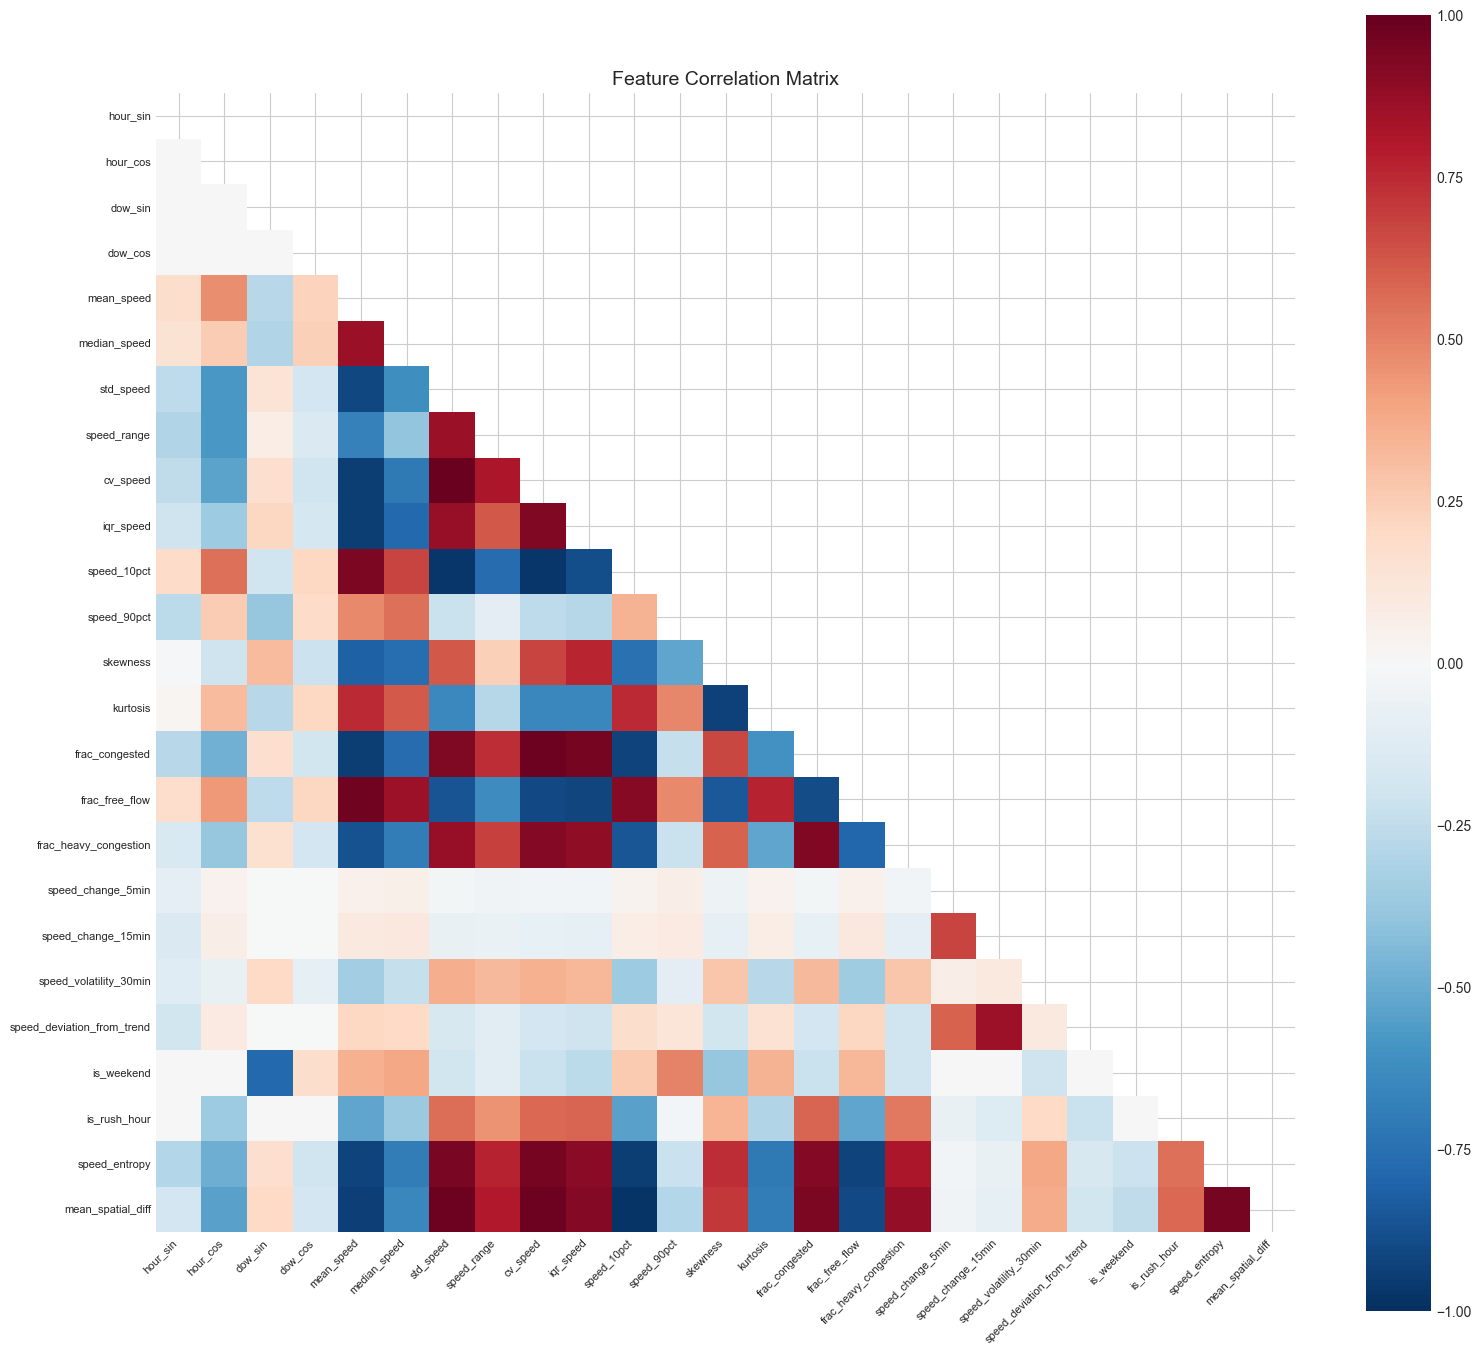


Highly correlated feature pairs (|r| > 0.9):
  mean_speed <-> std_speed: -0.908
  mean_speed <-> cv_speed: -0.952
  mean_speed <-> iqr_speed: -0.949
  mean_speed <-> speed_10pct: 0.943
  mean_speed <-> frac_congested: -0.948
  mean_speed <-> frac_free_flow: 0.976
  mean_speed <-> speed_entropy: -0.927
  mean_speed <-> mean_spatial_diff: -0.938
  std_speed <-> cv_speed: 0.987
  std_speed <-> speed_10pct: -0.971
  std_speed <-> frac_congested: 0.937
  std_speed <-> speed_entropy: 0.951
  std_speed <-> mean_spatial_diff: 0.981
  cv_speed <-> iqr_speed: 0.927
  cv_speed <-> speed_10pct: -0.970
  cv_speed <-> frac_congested: 0.977
  cv_speed <-> frac_free_flow: -0.905
  cv_speed <-> frac_heavy_congestion: 0.921
  cv_speed <-> speed_entropy: 0.954
  cv_speed <-> mean_spatial_diff: 0.981
  iqr_speed <-> frac_congested: 0.953
  iqr_speed <-> frac_free_flow: -0.918
  iqr_speed <-> mean_spatial_diff: 0.914
  speed_10pct <-> frac_congested: -0.927
  speed_10pct <-> frac_free_flow: 0.913
  speed_

In [13]:

# ---- Cell 12: Feature Correlation Analysis ----
# Check correlations between features to understand redundancy

fig, ax = plt.subplots(figsize=(16, 14))
corr_matrix = X_scaled.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('../data/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify highly correlated feature pairs
print("\nHighly correlated feature pairs (|r| > 0.9):")
for i in range(len(clustering_features)):
    for j in range(i+1, len(clustering_features)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.9:
            print(f"  {clustering_features[i]} <-> {clustering_features[j]}: {r:.3f}")


In [15]:

# ---- Cell 13: Save Engineered Features ----
# Save all features for use in subsequent notebooks

# FIX: Ensure all columns are HDF5-compatible (no nullable IntegerArrays,
# no object/string columns) before saving.
#
# - 'time_period' is a string column — drop it (already encoded as period_* dummies)
# - Boolean columns from get_dummies may be pandas BooleanDtype — cast to int
# - Any remaining object columns are converted to str as a safety net

temporal_df_to_save = temporal_df.drop(columns=['time_period'])

# Cast boolean columns (period_* dummies) to plain int8
bool_cols = temporal_df_to_save.select_dtypes(include=['bool', 'boolean']).columns
for col in bool_cols:
    temporal_df_to_save[col] = temporal_df_to_save[col].astype('int8')

# Safety net: convert any remaining object columns to string
obj_cols = temporal_df_to_save.select_dtypes(include=['object']).columns
for col in obj_cols:
    temporal_df_to_save[col] = temporal_df_to_save[col].astype(str)

# Save the full temporal features DataFrame
temporal_df_to_save.to_hdf('../data/temporal_features.h5', key='df', mode='w')
print(f"Full temporal features saved: {temporal_df_to_save.shape}")

# Save the scaled feature matrix for clustering
X_scaled.to_hdf('../data/features_scaled.h5', key='df', mode='w')
print(f"Scaled feature matrix saved: {X_scaled.shape}")

# Save the unscaled feature matrix
X.to_hdf('../data/features_unscaled.h5', key='df', mode='w')
print(f"Unscaled feature matrix saved: {X.shape}")

# Save feature names
import json
with open('../data/feature_names.json', 'w') as f:
    json.dump(clustering_features, f)
print(f"Feature names saved: {len(clustering_features)} features")

# Save the scaler for later use
import pickle
with open('../data/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved for later inverse transform")

print("\n" + "=" * 60)
print("NOTEBOOK 2 COMPLETE")
print("=" * 60)

Full temporal features saved: (34272, 49)
Scaled feature matrix saved: (34272, 25)
Unscaled feature matrix saved: (34272, 25)
Feature names saved: 25 features
Scaler saved for later inverse transform

NOTEBOOK 2 COMPLETE
